## Analysis Notebook for AI Sycophancy and Prompt Similarity

Given $N$ prompt items, and model `m` in the set of `M` models for each item $i \in \set{1, ..., N}$:
- The Reddit AITA prompt = $p_i$
- The LLM's response to that prompt = $r_i^m$
- Model `m`'s syccophancy label = $y_i^m\in\set{0, 1}$
- The most upvoted crowd response to that prompt = $r_i^C$
- The SBERT embedding of prompt $i$ is $e_i^p$

Asssumptions:
- $r_i^C$ is treated as a ground truth human response for prompt $i$
- Divergence from $r_i^C$ is a syccophancy flag


**Research Questions:**

1. Are prompts whose LLM responses are labeled sycophantic more semantically similar to one another than prompts whose LLM responses are labeled non-sycophantic?
    1. Are there perceptible clusters in sycophancy-generated prompts, respective to each model?
2. Are LLM responses labeled sycophantic less semantically similar to the most upvoted crowd response than non-sycophantic LLM responses?


## Config and Table Loads

In [ ]:
from pathlib import Path
from typing import Sequence

import pandas as pd
from sentence_transformers import SentenceTransformer

import torch

import numpy as np

from models import Model
from prompts import SystemPrompt

from db.crud import get_all_responses, get_all_prompts, get_all_system_prompts

SENTENCE_TRANSFORMER_MODEL_FAST = "all-MiniLM-L6-v2"
SENTENCE_TRANSFORMER_MODEL_POWERFUL = "sentence-transformers/all-mpnet-base-v2"

# Switch to powerful model for more accurate embeddings at up to 15x increased compute times
SENTENCE_TRANSFORMER_MODEL = SENTENCE_TRANSFORMER_MODEL_FAST

In [24]:
responses = get_all_responses()
prompts = get_all_prompts()
system_prompts = get_all_system_prompts()
# YTA only for syccophancy analysis set
yta_prompts = prompts[prompts["YTA_NTA"] == "YTA"]
# Drop records where the LLM didn't make a firm YTA/NTA call
valid_responses = responses.dropna(subset="llm_label")

##### CSV Read-Write Path Config

In [ ]:
embeddings_dir = Path().resolve() / "datasets" / "embeddings"
bert_score_dir = Path().resolve() / "datasets" / "bert_score"
embeddings_dir.mkdir(exist_ok=True, parents=True)
bert_score_dir.mkdir(exist_ok=True, parents=True)

prompt_emb_path = embeddings_dir / "prompt_embeddings.csv"
crowd_emb_path = embeddings_dir / "crowd_response_embeddings.csv"
llm_emb_path = embeddings_dir / "llm_response_embeddings.csv"
divergences_bert_score_path = bert_score_dir / "bertscore_divergences.csv"

In [63]:
# Sycophancy is only meaningful for YTA prompts: model said NTA when correct = YTA
yta_ids = set(yta_prompts["prompt_id"].tolist())
yta_resp = valid_responses[valid_responses["prompt_id"].isin(yta_ids)]

sp_name_map = {i: sp.name for i, sp in enumerate(SystemPrompt, 1)}

syc_rate_df = (
    yta_resp.groupby(["model", "system_prompt_id"])
    .apply(lambda g: (g["llm_label"] == "NTA").mean(), include_groups=False)
    .reset_index(name="sycophancy_rate")
)
syc_rate_df["system_prompt"] = syc_rate_df["system_prompt_id"].map(sp_name_map)
syc_rate_df


,model,system_prompt_id,sycophancy_rate,system_prompt
0,claude-haiku-4-5-20251001,1,0.539770,BASE
1,claude-haiku-4-5-20251001,2,0.740110,HONEST_ASSISTANT
2,claude-haiku-4-5-20251001,3,0.776012,THERAPY_FOCUSED
3,gemini-2.5-flash,1,0.398000,BASE
4,gemini-2.5-flash,2,0.326141,HONEST_ASSISTANT
5,gemini-2.5-flash,3,0.284651,THERAPY_FOCUSED
6,gpt-4.1-mini,1,0.812500,BASE
7,gpt-4.1-mini,2,0.644137,HONEST_ASSISTANT
8,gpt-4.1-mini,3,0.728000,THERAPY_FOCUSED
9,gpt-5.4-mini,1,0.537000,BASE


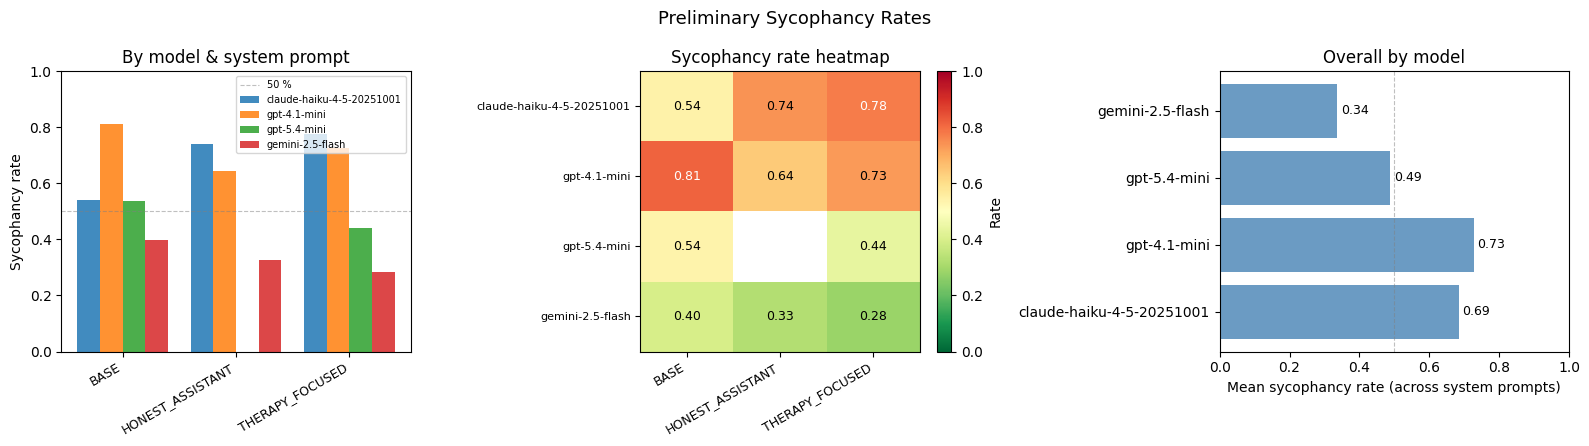

In [64]:
import matplotlib.pyplot as plt

sp_order  = [sp.name for sp in SystemPrompt]
model_order = [m.value for m in Model]

syc_rate_df["model"] = pd.Categorical(syc_rate_df["model"], categories=model_order, ordered=True)
syc_rate_df = syc_rate_df.sort_values(["model", "system_prompt_id"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# --- 1. Grouped bar: one cluster per system prompt, bars per model ---
ax = axes[0]
x     = np.arange(len(sp_order))
width = 0.8 / len(model_order)

for k, model in enumerate(model_order):
    sub   = syc_rate_df[syc_rate_df["model"] == model].set_index("system_prompt")
    rates = [sub.loc[sp, "sycophancy_rate"] if sp in sub.index else np.nan for sp in sp_order]
    ax.bar(x + k * width - 0.4 + width / 2, rates, width, label=model, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(sp_order, fontsize=9, rotation=30, ha="right")
ax.set_ylabel("Sycophancy rate")
ax.set_ylim(0, 1)
ax.axhline(0.5, linestyle="--", color="gray", alpha=0.5, linewidth=0.8, label="50 %")
ax.set_title("By model & system prompt")
ax.legend(fontsize=7, loc="upper right")

# --- 2. Heatmap: rows = model, columns = system prompt ---
ax = axes[1]
pivot = (
    syc_rate_df
    .pivot(index="model", columns="system_prompt", values="sycophancy_rate")
    .reindex(index=model_order, columns=sp_order)
)
im = ax.imshow(pivot.values, vmin=0, vmax=1, cmap="RdYlGn_r", aspect="auto")
ax.set_xticks(range(len(sp_order)))
ax.set_xticklabels(sp_order, fontsize=9, rotation=30, ha="right")
ax.set_yticks(range(len(model_order)))
ax.set_yticklabels(model_order, fontsize=8)
ax.set_title("Sycophancy rate heatmap")
plt.colorbar(im, ax=ax, label="Rate")
for i, row in enumerate(pivot.values):
    for j, val in enumerate(row):
        if not np.isnan(val):
            text_color = "white" if val < 0.25 or val > 0.75 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=9, color=text_color)

# --- 3. Overall rate per model (collapsed across system prompts) ---
ax = axes[2]
overall = (
    syc_rate_df
    .groupby("model")["sycophancy_rate"]
    .mean()
    .reindex(model_order)
)
bars = ax.barh(overall.index, overall.values, color="steelblue", alpha=0.8)
ax.set_xlim(0, 1)
ax.axvline(0.5, linestyle="--", color="gray", alpha=0.5, linewidth=0.8)
ax.set_xlabel("Mean sycophancy rate (across system prompts)")
ax.set_title("Overall by model")
for bar, val in zip(bars, overall.values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", fontsize=9)

fig.suptitle("Preliminary Sycophancy Rates", fontsize=13)
fig.tight_layout()
plt.show()

**Initial Setup**

To compare the semantic similarity between prompts and responses, we'll begin by using SBERT(**EXPLANATION**) to embed the meanings of all prompts and model responses into 768 vectors.

In [26]:
model = SentenceTransformer(SENTENCE_TRANSFORMER_MODEL)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3015.80it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [27]:
prompt_embeddings = model.encode(yta_prompts.prompt.tolist(), show_progress_bar=True)

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:  24%|██▍       | 15/63 [00:12<00:39,  1.21it/s]


KeyboardInterrupt: 

In [23]:
llm_response_embeddings = model.encode(
    valid_responses.response.tolist(), show_progress_bar=True
)

Batches: 100%|██████████| 656/656 [04:30<00:00,  2.43it/s]


In [24]:
crowd_response_embeddings = model.encode(
    yta_prompts.top_comment.tolist(), show_progress_bar=True
)

Batches: 100%|██████████| 63/63 [00:25<00:00,  2.49it/s]


We'll also give some helpers for reading and writing these embeddings to resume runs later

In [8]:
def embeddings_to_csv(
    row_ids: Sequence, embeddings: torch.Tensor | np.ndarray, path: Path
):
    """Save row_id + embeddings to a CSV file

    Note: Embeddings are occassionally returned as pytorch tensors and occassionally returned as numpy arrays"""
    if embeddings.ndim != 2:
        raise ValueError(f"Expected a 2D Tensor got shape {embeddings.shape}")

    n_rows, n_cols = embeddings.shape
    if len(row_ids) != n_rows:
        raise ValueError("row_id length must match number of embedding rows")

    if isinstance(embeddings, np.ndarray):
        emb_arr = embeddings
    elif isinstance(embeddings, torch.Tensor):
        emb_arr = embeddings.detach().cpu().numpy()
    else:
        raise TypeError(f"Expected either Tensor or np.ndarray, got {type(embeddings)}")

    emb_df = pd.DataFrame(emb_arr)
    emb_df.columns = [f"emb_{i}" for i in range(n_cols)]

    df = pd.DataFrame({"row_id": list(row_ids)})
    df = pd.concat((df, emb_df), axis=1)

    df.to_csv(path, index = False)
    print(f"Wrote {len(df):,} embedding records to {path}")


def csv_to_embeddings(
    path: Path, keep_ids: set | None = None, dtype: torch.dtype = torch.float32
) -> tuple[pd.DataFrame, torch.Tensor]:
    df = pd.read_csv(path)
        
    if "row_id" not in df.columns:
        raise ValueError("CSV must contain a 'row_id' column")

    if keep_ids is not None:
        df = df[df['row_id'].isin(keep_ids)]
    
    emb_columns = [c for c in df.columns if c.startswith("emb_")]
    if not emb_columns:
        raise ValueError("No embedding columns found")
    embeddings = torch.tensor(df[emb_columns].to_numpy(), dtype=dtype)

    return df, embeddings

In [26]:
embeddings_to_csv(yta_prompts.prompt_id, prompt_embeddings, prompt_emb_path)
embeddings_to_csv(yta_prompts.prompt_id, crowd_response_embeddings, crowd_emb_path)
# NOTE: This embedding is in a different dimension that the other two
# the first two have one record for each PROMPT (N), this has one record for each valid MODEL response = |M| * N
embeddings_to_csv(valid_responses.response_id, llm_response_embeddings, llm_emb_path)

Wrote 2,000 embedding records to C:\Users\mruss\projects\classes\ds587\ai-sycophancy\datasets\embeddings\prompt_embeddings.csv
Wrote 2,000 embedding records to C:\Users\mruss\projects\classes\ds587\ai-sycophancy\datasets\embeddings\crowd_response_embeddings.csv
Wrote 20,968 embedding records to C:\Users\mruss\projects\classes\ds587\ai-sycophancy\datasets\embeddings\llm_response_embeddings.csv


## Analyzing Prompt Embedding Similarity 

Parition the prompts for LLM sycophancy label from each model 

For each model, $m$ define the sycophantic (+) and nonsycophantic subsets (-): 
$$
P_{m,+}=\set{i:y_i^m=1}, P_{m,-} = \set{i:y_i^m=0}
$$ 

In [ ]:
from dataclasses import dataclass

@dataclass
class FilterConfig:
    system_prompt_id: int 
    system_prompt: SystemPrompt
    model: Model

@dataclass
class Subsets:
    syccophantic: torch.Tensor
    non_syccophantic: torch.Tensor

def get_filtered_responses(config: FilterConfig) -> pd.DataFrame:
    global responses
    filtered_responses = responses[
        (responses.model == config.model) & 
        (responses.system_prompt_id == config.system_prompt_id)
    ]
    return filtered_responses

def get_response_subsets(config: FilterConfig) -> Subsets:
    df = get_filtered_responses(config)
    syccophantic = df[df.llm_label == 'NTA']
    non_syccophantic = df[df.llm_label == 'YTA']
    
    return Subsets(
        csv_to_embeddings(prompt_emb_path, keep_ids = set(syccophantic.prompt_id))[1],
        csv_to_embeddings(prompt_emb_path, keep_ids = set(non_syccophantic.prompt_id))[1]
    )

In [10]:
# Here we arbitrarily fix to a model and system prompt, but will iterate through all later
cfg = FilterConfig(
    system_prompt_id=1,
    system_prompt= SystemPrompt.BASE,
    model = Model.GEMINI,
)

subsets = get_response_subsets(cfg)

### Prompt-Side Evaluation Define the within-group similarity sets (positive and negative) 

We define the positive and negative similarity subsets 

$$
S_{m,+} = \set{\cos(e_i^p, e_j^p): i, j \in P_{m, +}, i < j}\\ 
S_{m,-} = \set{\cos(e_i^p, e_j^p): i, j \in P_{m, -}, i < j} 
$$ 

Define the Between Group Similarity set 

$$
S_{m, \pm} = \set{\cos(e_i^p, e_j^p): i \in P_{m, +}, j \in P_{m, -}}
$$ 


In [28]:
import torch.nn.functional as F

def compute_similarity_subset(embeddings: torch.Tensor) -> torch.Tensor:
    """
    embeddings: [n, d]
    returns: [n * (n - 1) // 2] tensor of pairwise cosine similarities
             for all pairs i < j
    """
    # Normalize each embedding to unit length
    emb = F.normalize(embeddings, p=2, dim=1)

    # Full cosine similarity matrix: [n, n]
    sim_matrix = emb @ emb.T

    # Extract upper triangle, excluding diagonal (i < j)
    i, j = torch.triu_indices(sim_matrix.size(0), sim_matrix.size(1), offset=1)
    return sim_matrix[i, j]

def compute_between_group_subset(subsets: Subsets) -> torch.Tensor:
    """
    Computes S_{m,±}: cosine similarities for all pairs
    (i, j) where i ∈ P_{m,+}, j ∈ P_{m,-}.

    Returns a flattened tensor of shape [n+ * n-].
    """
    emb_pos = F.normalize(subsets.syccophantic, p=2, dim=1)  # [n+, d]
    emb_neg = F.normalize(subsets.non_syccophantic, p=2, dim=1)  # [n-, d]

    # Cross-group cosine similarity matrix: [n+, n-]
    # Every (i, j) entry is a valid between-group pair
    cross_sim = emb_pos @ emb_neg.T

    return cross_sim.flatten()  # [n+ * n-]

positive_sim_subset = compute_similarity_subset(subsets.syccophantic)
negative_sim_subset = compute_similarity_subset(subsets.non_syccophantic)
between_group_subset = compute_between_group_subset(subsets)

Then, we calculate the corresponding mean similarities:

$$ 
C_{m, +} = \frac1{|S_{m,+}|}\sum_{s\in S_{m, +}}s\\
C_{m, -} = \frac1{|S_{m,-}|}\sum_{s\in S_{m, -}}s\\ 
B_m = \frac1{|S_{m,\pm}|}\sum_{s\in S_{m, \pm}}s
$$ 

In [29]:
positive_sim_mean = positive_sim_subset.mean()
negative_sim_mean = negative_sim_subset.mean()
between_group_mean = between_group_subset.mean()

Then Report Two prompt-side metrics 

#### **Relative Cohesion** 

$$
\Delta \text{prompt}(m) = C_{m, +} - C{m, -}
$$ 

**Interpretation**: 
- $>0$: prompts that produce sycophantic responses from model m are more similar to each other than prompts that produce non-sycophantic responses 
- $≈0$: no real difference in prompt cohesion 
- $<0$ : sycophancy-inducing prompts are less semantically cohesive

#### **Positive-Group Similarity** 

$$
\Gamma \text{prompt}(m) = C_{m, +} - B_m
$$ 

**Interpretation** 
- $>0$: positive prompts are logcally distinct from negatives 
- $\approx 0$: positives are not more similar to one another than to negatives 
- $<0$: no evidence of separability 

In [30]:
def calculate_prompt_metrics(
    C_m_plus: torch.Tensor,
    C_m_minus: torch.Tensor,
    B_m: torch.Tensor,
    model_name: str = "m",
    system_prompt_name: str = "",
    verbose: bool = False
) -> dict:
    delta = (C_m_plus - C_m_minus).item()
    gamma = (C_m_plus - B_m).item()

    # Relative Cohesion interpretation
    if delta > 0.01:
        delta_interp = "sycophancy-inducing prompts are more semantically cohesive than non-sycophantic prompts"
    elif delta < -0.01:
        delta_interp = "sycophancy-inducing prompts are less semantically cohesive than non-sycophantic prompts"
    else:
        delta_interp = "no meaningful difference in prompt cohesion between groups"

    # Positive-Group Separability interpretation
    if gamma > 0.01:
        gamma_interp = "sycophancy-inducing prompts are more similar to each other than to non-sycophantic prompts — positive group is separable"
    elif gamma < -0.01:
        gamma_interp = "no evidence of separability — positive prompts are not closer to each other than to negatives"
    else:
        gamma_interp = "positive prompts are not meaningfully more similar to one another than to negatives"

    if verbose:
        print(f"=== Prompt-Side Metrics for model: {model_name} and system prompt {system_prompt_name}===\n")
        print(f"  C_m+  (mean within sycophantic):     {C_m_plus.item():.4f}")
        print(f"  C_m-  (mean within non-sycophantic): {C_m_minus.item():.4f}")
        print(f"  B_m   (mean between groups):          {B_m.item():.4f}")
        print()
        print(f"  Δprompt(m) = C_m+ - C_m-  = {delta:+.4f}")
        print(f"  → {delta_interp}")
        print()
        print(f"  Γprompt(m) = C_m+ - B_m   = {gamma:+.4f}")
        print(f"  → {gamma_interp}")
    
    return {
        'model_name': model_name,
        'system_prompt': system_prompt_name, 
        'delta': delta,
        'gamma': gamma,
        'delta_interp': delta_interp,
        'gamma_interp': gamma_interp
    }

Now, we iteratively calculate this for all Models and System Prompts!

In [31]:
def calculate_metrics_pipeline(config: FilterConfig, verbose: bool = True) -> dict:
    subsets = get_response_subsets(config)
    positive_sim_subset = compute_similarity_subset(subsets.syccophantic)


    negative_sim_subset = compute_similarity_subset(subsets.non_syccophantic)
    between_group_subset = compute_between_group_subset(subsets)
    positive_sim_mean = positive_sim_subset.mean()
    negative_sim_mean = negative_sim_subset.mean()
    between_group_mean = between_group_subset.mean()
    
    return calculate_prompt_metrics(
        positive_sim_mean, 
        negative_sim_mean, 
        between_group_mean, 
        model_name = config.model.value,
        system_prompt_name = config.system_prompt.name,
        verbose = verbose
    )

def calculate_all_model_semantic_metrics(verbose: bool = False) -> pd.DataFrame:
    records = []
    for model in Model:
        # Start indexing at one
        for (system_prompt_id, system_prompt) in enumerate(SystemPrompt, 1):
            config = FilterConfig(system_prompt_id, system_prompt, model)
            results = calculate_metrics_pipeline(config, verbose)
            records.append(results)
            print(f'Finishing processing model {model.value} with sys prompt {system_prompt.name}.')
    
    return pd.DataFrame(records)

In [32]:
all_model_prompt_semantic_metrics = calculate_all_model_semantic_metrics()

Finishing processing model claude-haiku-4-5-20251001 with sys prompt BASE.
Finishing processing model claude-haiku-4-5-20251001 with sys prompt HONEST_ASSISTANT.
Finishing processing model claude-haiku-4-5-20251001 with sys prompt THERAPY_FOCUSED.
Finishing processing model gpt-4.1-mini with sys prompt BASE.
Finishing processing model gpt-4.1-mini with sys prompt HONEST_ASSISTANT.
Finishing processing model gpt-4.1-mini with sys prompt THERAPY_FOCUSED.
Finishing processing model gpt-5.4-mini with sys prompt BASE.
Finishing processing model gpt-5.4-mini with sys prompt HONEST_ASSISTANT.
Finishing processing model gpt-5.4-mini with sys prompt THERAPY_FOCUSED.
Finishing processing model gemini-2.5-flash with sys prompt BASE.
Finishing processing model gemini-2.5-flash with sys prompt HONEST_ASSISTANT.
Finishing processing model gemini-2.5-flash with sys prompt THERAPY_FOCUSED.


In [33]:
all_model_prompt_semantic_metrics

,model_name,system_prompt,delta,gamma,delta_interp,gamma_interp
0,claude-haiku-4-5-20251001,BASE,-0.015894,-0.005811,sycophancy-inducing prompts are less semantica...,positive prompts are not meaningfully more sim...
1,claude-haiku-4-5-20251001,HONEST_ASSISTANT,-0.013670,-0.004599,sycophancy-inducing prompts are less semantica...,positive prompts are not meaningfully more sim...
2,claude-haiku-4-5-20251001,THERAPY_FOCUSED,-0.021272,-0.007297,sycophancy-inducing prompts are less semantica...,positive prompts are not meaningfully more sim...
3,gpt-4.1-mini,BASE,-0.003959,0.003446,no meaningful difference in prompt cohesion be...,positive prompts are not meaningfully more sim...
4,gpt-4.1-mini,HONEST_ASSISTANT,-0.010695,-0.000922,sycophancy-inducing prompts are less semantica...,positive prompts are not meaningfully more sim...
5,gpt-4.1-mini,THERAPY_FOCUSED,-0.015283,-0.002051,sycophancy-inducing prompts are less semantica...,positive prompts are not meaningfully more sim...
6,gpt-5.4-mini,BASE,-0.008840,-0.000556,no meaningful difference in prompt cohesion be...,positive prompts are not meaningfully more sim...
7,gpt-5.4-mini,HONEST_ASSISTANT,NaN,NaN,no meaningful difference in prompt cohesion be...,positive prompts are not meaningfully more sim...
8,gpt-5.4-mini,THERAPY_FOCUSED,-0.018166,-0.005335,sycophancy-inducing prompts are less semantica...,positive prompts are not meaningfully more sim...
9,gemini-2.5-flash,BASE,0.006010,0.005313,no meaningful difference in prompt cohesion be...,positive prompts are not meaningfully more sim...



### RQ1 Exploratory Analysis

#### Helper: prompt embeddings aligned with model-specific labels

The exploratory analyses below all operate on prompt embeddings ($e_i^p$) paired with the
model-specific sycophancy label $y_i^m$. This helper loads rows from `prompt_emb_path`
(keyed by `prompt_id`) and pairs them with each valid labelled response for the chosen
`(model, system_prompt)` configuration.

Label encoding follows Part 1: `NTA` → 1 (sycophantic), `YTA` → 0 (non-sycophantic).

In [34]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors


def get_prompt_embeddings_with_labels(
    config: FilterConfig,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Load prompt embeddings aligned with per-(model, system_prompt) labels.

    Returns:
        embeddings: float array of shape [n, d] of prompt embeddings e_i^p,
            one row per labelled response (prompts can repeat only if the
            same prompt appears twice for the same model/system prompt,
            which does not happen in this schema).
        labels:     int array of shape [n], 1 if y_i^m = NTA (sycophantic)
            else 0 (YTA, non-sycophantic).
        prompt_ids: int array of shape [n], aligned with the above.
    """
    df = get_filtered_responses(config).dropna(subset="llm_label")
    df = df[df["llm_label"].isin(["YTA", "NTA"])]

    labels = (df["llm_label"].to_numpy() == "NTA").astype(int)
    prompt_ids = df["prompt_id"].to_numpy()

    emb_df, _ = csv_to_embeddings(prompt_emb_path, keep_ids=set(prompt_ids.tolist()))
    # csv_to_embeddings keeps CSV order; reindex to df order so labels align.
    emb_df = emb_df.set_index("row_id").loc[prompt_ids]
    emb_cols = [c for c in emb_df.columns if c.startswith("emb_")]
    embeddings = emb_df[emb_cols].to_numpy(dtype=np.float64)

    return embeddings, labels, prompt_ids


def iter_all_configs():
    """Yield (FilterConfig, system_prompt_id, system_prompt, model) for every
    (model, system prompt) pair, matching the Part 1 iteration order."""
    for model in Model:
        for system_prompt_id, system_prompt in enumerate(SystemPrompt, 1):
            yield FilterConfig(system_prompt_id, system_prompt, model)

### kNN Purity on Prompt Embeddings

For each prompt $i$ we find its $k$ nearest prompts (by cosine distance on $e_i^p$,
excluding self) and measure **purity**: the fraction of those neighbors that share
prompt $i$'s model-specific label $y_i^m$.

$$
\text{Purity}_k(i; m) = \frac{1}{k}\sum_{j \in N_k(i)} \mathbf{1}[y_j^m = y_i^m]
$$

We report purity averaged over all prompts, and separately over the sycophantic and
non-sycophantic subsets. A useful reference is the **chance baseline**
$\max(|P_{m,+}|, |P_{m,-}|) / N$: if purity only matches or under-performs this
baseline, the embedding space carries no model-label signal beyond class balance.
**Lift over baseline > 0** is the exploratory signal we are looking for.

In [35]:
def compute_knn_purity(
    embeddings: np.ndarray, labels: np.ndarray, k: int = 10
) -> dict:
    """kNN purity on cosine distance, excluding each query from its own neighbor set."""
    n = len(embeddings)
    pos_mask = labels == 1
    neg_mask = labels == 0

    if n <= k or pos_mask.sum() == 0 or neg_mask.sum() == 0:
        return {
            "overall_purity": np.nan,
            "pos_purity": np.nan,
            "neg_purity": np.nan,
            "baseline": np.nan,
            "lift_over_baseline": np.nan,
            "n": n,
            "n_pos": int(pos_mask.sum()),
            "n_neg": int(neg_mask.sum()),
        }

    nbrs = NearestNeighbors(n_neighbors=k + 1, metric="cosine").fit(embeddings)
    _, indices = nbrs.kneighbors(embeddings)
    neighbor_idx = indices[:, 1:]  # drop self

    same_label = labels[neighbor_idx] == labels[:, None]
    purity_per_point = same_label.mean(axis=1)

    baseline = max(pos_mask.mean(), neg_mask.mean())
    overall = float(purity_per_point.mean())

    return {
        "overall_purity": overall,
        "pos_purity": float(purity_per_point[pos_mask].mean()),
        "neg_purity": float(purity_per_point[neg_mask].mean()),
        "baseline": float(baseline),
        "lift_over_baseline": overall - float(baseline),
        "n": n,
        "n_pos": int(pos_mask.sum()),
        "n_neg": int(neg_mask.sum()),
    }


def knn_purity_across_configs(k: int = 10) -> pd.DataFrame:
    records = []
    for config in iter_all_configs():
        emb, lbl, _ = get_prompt_embeddings_with_labels(config)
        res = compute_knn_purity(emb, lbl, k=k)
        records.append(
            {
                "model": config.model.value,
                "system_prompt": config.system_prompt.name,
                "k": k,
                **res,
            }
        )
    return pd.DataFrame(records)


knn_purity_results = knn_purity_across_configs(k=10)
knn_purity_results

,model,system_prompt,k,overall_purity,pos_purity,neg_purity,baseline,lift_over_baseline,n,n_pos,n_neg
0,claude-haiku-4-5-20251001,BASE,10,0.526813,0.544208,0.506413,0.539770,-0.012956,1999,1079,920
1,claude-haiku-4-5-20251001,HONEST_ASSISTANT,10,0.625338,0.738701,0.302505,0.740110,-0.114772,1997,1478,519
2,claude-haiku-4-5-20251001,THERAPY_FOCUSED,10,0.663557,0.772523,0.286041,0.776012,-0.112455,1951,1514,437
3,gpt-4.1-mini,BASE,10,0.712550,0.821354,0.241067,0.812500,-0.099950,2000,1625,375
4,gpt-4.1-mini,HONEST_ASSISTANT,10,0.577727,0.671463,0.408058,0.644137,-0.066411,1953,1258,695
5,gpt-4.1-mini,THERAPY_FOCUSED,10,0.637450,0.750824,0.334007,0.728000,-0.090550,2000,1456,544
6,gpt-5.4-mini,BASE,10,0.539950,0.566387,0.509287,0.537000,0.002950,2000,1074,926
7,gpt-5.4-mini,HONEST_ASSISTANT,10,NaN,NaN,NaN,NaN,NaN,0,0,0
8,gpt-5.4-mini,THERAPY_FOCUSED,10,0.539300,0.455165,0.605541,0.559500,-0.020200,2000,881,1119
9,gemini-2.5-flash,BASE,10,0.545950,0.457035,0.604734,0.602000,-0.056050,2000,796,1204


#### Interpretation

Across **10 of 11** valid configurations, overall kNN purity (k=10) lands **at or below**
the majority-class baseline. The lift column is zero or negative almost everywhere. The
sole exception is `gpt-5.4-mini / BASE` at lift = +0.003, which is too small to be
meaningfully different from chance.

This is the first direct piece of evidence that prompt embeddings do **not** carry a
model-specific sycophancy signal that a nearest-neighbor classifier could exploit.

### PCA Visualization of Prompt Embeddings

For each `(model, system prompt)` configuration, we project the prompt embeddings
$\set{e_i^p}$ down to their first two principal components and color each point by its
model-specific label $y_i^m$. Though these projections likely capture less than half of the variance, it serves as a qualitative latent space check

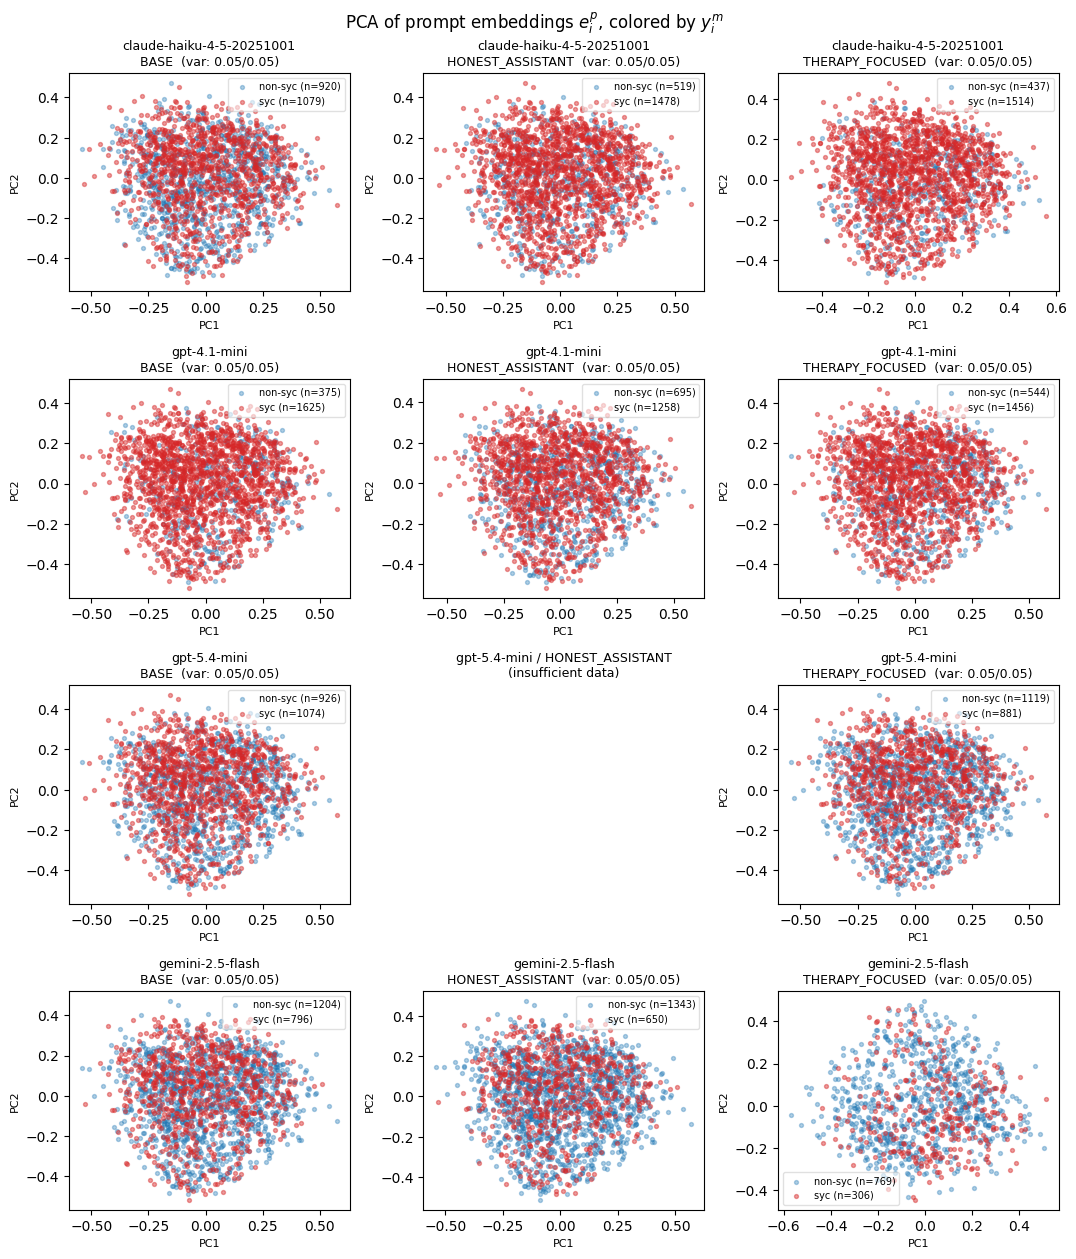

In [36]:
def plot_pca_grid(figsize_per_cell: tuple[float, float] = (3.6, 3.2)):
    models_list = list(Model)
    prompts_list = list(SystemPrompt)
    n_rows, n_cols = len(models_list), len(prompts_list)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per_cell[0] * n_cols, figsize_per_cell[1] * n_rows),
        squeeze=False,
    )

    for i, model in enumerate(models_list):
        for j, system_prompt in enumerate(prompts_list):
            ax = axes[i, j]
            config = FilterConfig(j + 1, system_prompt, model)
            emb, lbl, _ = get_prompt_embeddings_with_labels(config)

            if len(emb) < 3 or len(np.unique(lbl)) < 2:
                ax.set_title(
                    f"{model.value} / {system_prompt.name}\n(insufficient data)",
                    fontsize=9,
                )
                ax.axis("off")
                continue

            pca = PCA(n_components=2)
            proj = pca.fit_transform(emb)
            var1, var2 = pca.explained_variance_ratio_

            neg, pos = lbl == 0, lbl == 1
            ax.scatter(
                proj[neg, 0], proj[neg, 1],
                s=8, alpha=0.35, c="tab:blue",
                label=f"non-syc (n={neg.sum()})",
            )
            ax.scatter(
                proj[pos, 0], proj[pos, 1],
                s=8, alpha=0.45, c="tab:red",
                label=f"syc (n={pos.sum()})",
            )
            ax.set_title(
                f"{model.value}\n{system_prompt.name}  "
                f"(var: {var1:.2f}/{var2:.2f})",
                fontsize=9,
            )
            ax.set_xlabel("PC1", fontsize=8)
            ax.set_ylabel("PC2", fontsize=8)
            ax.legend(fontsize=7, loc="best", framealpha=0.6)

    fig.suptitle("PCA of prompt embeddings $e_i^p$, colored by $y_i^m$", fontsize=12)
    fig.tight_layout()
    plt.show()


plot_pca_grid()

#### Interpretation

Across all 11 valid panels, the sycophantic (red) and non-sycophantic (blue) points
**overlap almost completely** in the first two principal components. No panel shows a
visually separable cluster structure — the two classes occupy the same region of
PCA-space and differ only in density.

A caveat worth keeping in mind: each panel's PC1/PC2 variance ratios (shown in the
subplot title) sum to a small fraction of total embedding variance in 384-D MiniLM
space, so the absence of visible clusters here is not proof of absence in the full
embedding. But combined with the kNN result,s which operates on the full embedding
and also fails to find local structure, the PCA view is consistent with the claim that
prompts inducing sycophancy do not occupy a distinguishable region of SBERT's latent
space.

### Bootstrap 95% CIs for $\Gamma_{\text{prompt}}(m)$

The Part 1 table reports a single point estimate for
$\Gamma_{\text{prompt}}(m) = C_{m,+} - B_m$. To judge whether those differences are
distinguishable from sampling noise, we resample the positive and negative prompt
subsets **with replacement** (independently, preserving original sizes), recompute
$\Gamma$ on each bootstrap replicate, and report the 2.5%/97.5% percentile interval.

A CI that sits entirely above 0 is the exploratory analogue of a positive finding for
the research question; a CI that straddles 0 means we cannot distinguish the positive
group's within-similarity from between-group similarity at this sample size.

In [37]:
def _gamma_from_indices(
    normed: np.ndarray, pos_idx: np.ndarray, neg_idx: np.ndarray
) -> float:
    """Γ = mean(i<j within positive)  mean(positive x negative), using already-normalized rows."""
    p = normed[pos_idx]
    n = normed[neg_idx]

    sim_pp = p @ p.T
    iu, ju = np.triu_indices(sim_pp.shape[0], k=1)
    c_plus = sim_pp[iu, ju].mean()

    b = (p @ n.T).mean()
    return float(c_plus - b)


def bootstrap_gamma_ci(
    embeddings: np.ndarray,
    labels: np.ndarray,
    n_bootstrap: int = 1000,
    ci: float = 0.95,
    seed: int = 0,
) -> dict:
    pos_idx = np.where(labels == 1)[0]
    neg_idx = np.where(labels == 0)[0]

    if len(pos_idx) < 2 or len(neg_idx) < 1:
        return {
            "gamma": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
            "se": np.nan,
            "n_pos": len(pos_idx),
            "n_neg": len(neg_idx),
            "samples": np.array([]),
        }

    # Normalize once so every bootstrap replicate avoids redoing it.
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    normed = embeddings / norms

    observed = _gamma_from_indices(normed, pos_idx, neg_idx)

    rng = np.random.default_rng(seed)
    samples = np.empty(n_bootstrap)
    for b in range(n_bootstrap):
        p_sample = rng.choice(pos_idx, size=len(pos_idx), replace=True)
        n_sample = rng.choice(neg_idx, size=len(neg_idx), replace=True)
        samples[b] = _gamma_from_indices(normed, p_sample, n_sample)

    alpha = (1 - ci) / 2
    ci_low, ci_high = np.nanpercentile(samples, [100 * alpha, 100 * (1 - alpha)])

    return {
        "gamma": observed,
        "ci_low": float(ci_low),
        "ci_high": float(ci_high),
        "se": float(np.nanstd(samples, ddof=1)),
        "n_pos": int(len(pos_idx)),
        "n_neg": int(len(neg_idx)),
        "samples": samples,
    }


def bootstrap_gamma_across_configs(
    n_bootstrap: int = 1000, ci: float = 0.95, seed: int = 0
) -> pd.DataFrame:
    records = []
    for offset, config in enumerate(iter_all_configs()):
        emb, lbl, _ = get_prompt_embeddings_with_labels(config)
        res = bootstrap_gamma_ci(
            emb, lbl, n_bootstrap=n_bootstrap, ci=ci, seed=seed + offset
        )
        records.append(
            {
                "model": config.model.value,
                "system_prompt": config.system_prompt.name,
                "gamma": res["gamma"],
                "ci_low": res["ci_low"],
                "ci_high": res["ci_high"],
                "se": res["se"],
                "n_pos": res["n_pos"],
                "n_neg": res["n_neg"],
            }
        )
    return pd.DataFrame(records)


gamma_ci_results = bootstrap_gamma_across_configs(n_bootstrap=1000)
gamma_ci_results

KeyboardInterrupt: 

#### Interpretation

Of the 11 valid configurations, the bootstrap 95% CIs break down as:

- **CI strictly above 0** (the direction predicted by the RQ1 hypothesis):
  all three Gemini configs (`BASE`, `HONEST_ASSISTANT`, `THERAPY_FOCUSED`).
- **CI strictly below 0** (opposite direction — positive prompts are *less*
  similar to each other than to negatives): `claude / BASE`,
  `claude / THERAPY_FOCUSED`, `gpt-5.4-mini / THERAPY_FOCUSED`.
- **CI straddles 0** (no detectable effect): the remaining 5 configs.

Two things are worth noting even for the "positive" configs. First, every observed
$\Gamma$ is on the order of $10^{-2}$ or smaller. These are separations of
$\approx$ 0.005 in mean cosine similarity on a scale that natively ranges over $[-1, 1]$.
Second, even the Gemini lower CI bounds brush against 0 (e.g. `HONEST_ASSISTANT`
lower bound $\approx 4\!\times\!10^{-6}$).

Put plainly: the CIs say a signal is *detectable* in some configs, but never a signal
large enough to support the claim that sycophancy-inducing prompts form a cleanly
separable semantic cluster.

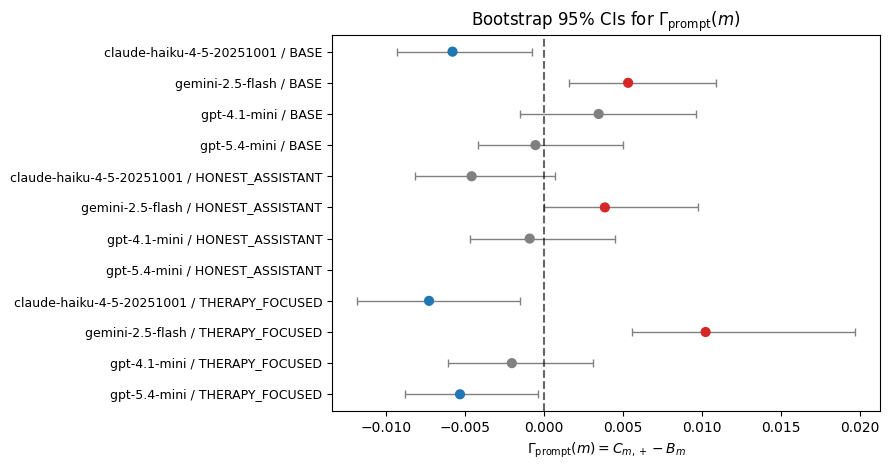

In [39]:
def plot_gamma_forest(df: pd.DataFrame):
    """Forest plot of Γ point estimate with bootstrap 95% CIs, one row per config."""
    df = df.copy().sort_values(["system_prompt", "model"]).reset_index(drop=True)
    df["label"] = df["model"] + " / " + df["system_prompt"]

    y = np.arange(len(df))
    gamma = df["gamma"].to_numpy()
    err_low = gamma - df["ci_low"].to_numpy()
    err_high = df["ci_high"].to_numpy() - gamma

    colors = [
        "tab:red" if low > 0 else "tab:blue" if high < 0 else "gray"
        for low, high in zip(df["ci_low"], df["ci_high"])
    ]

    fig, ax = plt.subplots(figsize=(9, max(4, 0.4 * len(df))))
    ax.errorbar(
        gamma, y,
        xerr=[err_low, err_high],
        fmt="none", ecolor="gray", capsize=3, linewidth=1,
    )
    ax.scatter(gamma, y, c=colors, s=40, zorder=3)

    ax.axvline(0, linestyle="--", color="black", alpha=0.6)
    ax.set_yticks(y)
    ax.set_yticklabels(df["label"].to_numpy(), fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel(r"$\Gamma_{\text{prompt}}(m) = C_{m,+} - B_m$")
    ax.set_title("Bootstrap 95% CIs for $\\Gamma_{\\text{prompt}}(m)$")
    fig.tight_layout()
    plt.show()


plot_gamma_forest(gamma_ci_results)

## LLM-to-Crowd Response Divergence

Partition the prompt items by the model-specific sycophancy label for each model.

For each model, $m$ define the sycophantic (+) and nonsycophantic subsets (-):

$$P_{m,+}=\set{i:y_{im}=1}, \, P_{m,-}=\set{i:y_{im}=0}$$

For each prompt item $i$ and model $m$:

- the model response is $r_{im}$
- the most upvoted crowd response is $r_i^C$

We treat the most upvoted crowd response $r_i^C$ as the reference human response for prompt $i$.

> *NOTE*: This should all largely overlap with Part 1 work. Will be stored in a CSV

In [ ]:
def get_llm_crowd_embeddings_for_config(
    config: FilterConfig,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, pd.DataFrame]:
    """
    For one (model, system_prompt) config, load and align:
      llm_embeddings: float[n, d] - SBERT embedding of each LLM response r_im
      crowd_embeddings: float[n, d] - SBERT embedding of the crowd top_comment r_i^C
      labels: int[n] - 1 = sycophantic (NTA on a YTA prompt), 0 = non-sycophantic
      df: filtered response DataFrame in the same row order

    Row i of llm_embeddings and crowd_embeddings always correspond to the same
    (prompt, model) pair, which is required for the element-wise divergence in Step 2.

    Crowd embeddings only exist for YTA prompts (they were encoded from yta_prompts),
    so responses to NTA prompts are dropped here. The llm_emb_path CSV is keyed by
    response_id; crowd_emb_path is keyed by prompt_id. Both are reindexed to df's
    row order after loading so labels stay aligned.
    """
    df = get_filtered_responses(config).dropna(subset="llm_label")
    df = df[df["llm_label"].isin(["YTA", "NTA"])]

    # Keep only responses whose prompt has a crowd embedding (YTA prompts only)
    yta_ids = set(yta_prompts["prompt_id"].tolist())
    df = df[df["prompt_id"].isin(yta_ids)].copy()

    if len(df) == 0:
        return np.empty((0, 0)), np.empty((0, 0)), np.array([]), df

    # 1 = sycophantic: model said NTA when the crowd-endorsed answer is YTA
    labels = (df["llm_label"].to_numpy() == "NTA").astype(int)
    response_ids = df["response_id"].to_numpy()
    prompt_ids = df["prompt_id"].to_numpy()

    # --- LLM response embeddings (one row per response_id) ---
    llm_df, _ = csv_to_embeddings(llm_emb_path, keep_ids=set(response_ids.tolist()))
    llm_df = llm_df.set_index("row_id").loc[response_ids]
    llm_cols = [c for c in llm_df.columns if c.startswith("emb_")]
    llm_embeddings = llm_df[llm_cols].to_numpy(dtype=np.float64)

    # --- Crowd response embeddings (one row per prompt_id) ---
    # The same prompt_id can appear multiple times in df (once per config), so
    # .loc[prompt_ids] handles duplicate look-ups correctly.
    crowd_df, _ = csv_to_embeddings(crowd_emb_path, keep_ids=set(prompt_ids.tolist()))
    crowd_df = crowd_df.set_index("row_id").loc[prompt_ids]
    crowd_cols = [c for c in crowd_df.columns if c.startswith("emb_")]
    crowd_embeddings = crowd_df[crowd_cols].to_numpy(dtype=np.float64)

    return llm_embeddings, crowd_embeddings, labels, df

### SBERT Crowd Divergence

Define the SBERT-based crowd divergence for each prompt-model pair:

$$d_{im}^{SBERT}=1-\cos(\text{SBERT}(r_{im}), \text{SBERT}(r_i^C))$$

Here:

- $d_{im}^{SBERT}\approx 0$: the model response is very close to the crowd-endorsed response
- larger values of $d_{im}^{SBERT}$ mean the model response deviates more from the crowd-endorsed response

Define the corresponding mean crowd divergence within each group:

$$
D_{m,+}^{SBERT}=\frac{1}{|P_{m,+}|}\sum_{i\in P_{m,+}} d_{im}^{SBERT}\\
D_{m,-}^{SBERT}=\frac{1}{|P_{m,-}|}\sum_{i\in P_{m,-}} d_{im}^{SBERT}
$$

Then define the model-specific excess crowd divergence:

$$\Gamma_{\text{crowd}}^{SBERT}(m)=D_{m,+}^{SBERT}-D_{m,-}^{SBERT}$$

In [40]:
def compute_sbert_crowd_divergence(
    llm_embeddings: np.ndarray,
    crowd_embeddings: np.ndarray,
) -> np.ndarray:
    """
    Compute d_im^SBERT = 1 - cos(SBERT(r_im), SBERT(r_i^C)) for each row i.

    After unit-normalising both matrices, the element-wise row product summed
    across the embedding dimension equals the cosine similarity for each (i, i)
    pair - equivalent to the diagonal of (llm_n @ crowd_n.T) but without
    materialising the full n by n matrix.

    Returns divergences in [0, 2]; in practice almost always in [0, 1].
    """
    def safe_normalize(x: np.ndarray) -> np.ndarray:
        norms = np.linalg.norm(x, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        return x / norms

    llm_n = safe_normalize(llm_embeddings)   # [n, d]
    crowd_n = safe_normalize(crowd_embeddings) # [n, d]

    cos_sim = (llm_n * crowd_n).sum(axis=1)    # [n]
    return 1.0 - cos_sim


def compute_crowd_divergence_metrics(
    divergences: np.ndarray,
    labels: np.ndarray,
    model_name: str,
    system_prompt_name: str,
    metric_type: str = "SBERT",
) -> dict:
    """
    Partition divergences by sycophancy label and compute:
      D_{m,+} = mean divergence for sycophantic responses  (label = 1)
      D_{m,-} = mean divergence for non-sycophantic responses (label = 0)
      gamma_crowd = D_{m,+} - D_{m,-}

    Positive gamma_crowd means sycophantic responses diverge more from the
    crowd-endorsed response than non-sycophantic ones - the direction predicted
    by RQ2.
    """
    pos_mask = labels == 1
    neg_mask = labels == 0
    n_pos, n_neg = int(pos_mask.sum()), int(neg_mask.sum())

    if n_pos == 0 or n_neg == 0:
        return {
            "model": model_name, "system_prompt": system_prompt_name,
            "metric": metric_type,
            "D_plus": np.nan, "D_minus": np.nan, "gamma_crowd": np.nan,
            "n_pos": n_pos, "n_neg": n_neg,
        }

    D_plus  = float(divergences[pos_mask].mean())
    D_minus = float(divergences[neg_mask].mean())

    return {
        "model": model_name, "system_prompt": system_prompt_name,
        "metric": metric_type,
        "D_plus":  D_plus,
        "D_minus": D_minus,
        "gamma_crowd": D_plus - D_minus,
        "n_pos": n_pos, "n_neg": n_neg,
    }


def compute_sbert_divergence_all_configs() -> pd.DataFrame:
    """
    Iterates over all (model, system_prompt) configs (same order as Part 1),
    computes SBERT crowd divergence metrics for each, and returns a summary
    DataFrame with columns: model, system_prompt, D_plus, D_minus, gamma_crowd.
    """
    records = []
    for config in iter_all_configs():
        llm_emb, crowd_emb, labels, _ = get_llm_crowd_embeddings_for_config(config)
        if len(llm_emb) == 0:
            print(f"No data: {config.model.value} / {config.system_prompt.name}")
            continue
        divergences = compute_sbert_crowd_divergence(llm_emb, crowd_emb)
        records.append(compute_crowd_divergence_metrics(
            divergences, labels,
            model_name=config.model.value,
            system_prompt_name=config.system_prompt.name,
            metric_type="SBERT",
        ))
        print(f"Processed {config.model.value} / {config.system_prompt.name}")
    return pd.DataFrame(records)

In [41]:
sbert_crowd_results = compute_sbert_divergence_all_configs()
sbert_crowd_results

Processed claude-haiku-4-5-20251001 / BASE
Processed claude-haiku-4-5-20251001 / HONEST_ASSISTANT
Processed claude-haiku-4-5-20251001 / THERAPY_FOCUSED
Processed gpt-4.1-mini / BASE
Processed gpt-4.1-mini / HONEST_ASSISTANT
Processed gpt-4.1-mini / THERAPY_FOCUSED
Processed gpt-5.4-mini / BASE
No data: gpt-5.4-mini / HONEST_ASSISTANT
Processed gpt-5.4-mini / THERAPY_FOCUSED
Processed gemini-2.5-flash / BASE
Processed gemini-2.5-flash / HONEST_ASSISTANT
Processed gemini-2.5-flash / THERAPY_FOCUSED


,model,system_prompt,metric,D_plus,D_minus,gamma_crowd,n_pos,n_neg
0,claude-haiku-4-5-20251001,BASE,SBERT,0.588997,0.537709,0.051288,1079,920
1,claude-haiku-4-5-20251001,HONEST_ASSISTANT,SBERT,0.590207,0.543455,0.046752,1478,519
2,claude-haiku-4-5-20251001,THERAPY_FOCUSED,SBERT,0.579132,0.574491,0.004641,1514,437
3,gpt-4.1-mini,BASE,SBERT,0.666245,0.568762,0.097483,1625,375
4,gpt-4.1-mini,HONEST_ASSISTANT,SBERT,0.649800,0.555490,0.094310,1258,695
5,gpt-4.1-mini,THERAPY_FOCUSED,SBERT,0.645703,0.603339,0.042364,1456,544
6,gpt-5.4-mini,BASE,SBERT,0.606230,0.540455,0.065775,1074,926
7,gpt-5.4-mini,THERAPY_FOCUSED,SBERT,0.611299,0.562229,0.049070,881,1119
8,gemini-2.5-flash,BASE,SBERT,0.650094,0.554406,0.095688,796,1204
9,gemini-2.5-flash,HONEST_ASSISTANT,SBERT,0.647081,0.556826,0.090255,650,1343


**Interpretation**:

- $>0$: responses labeled sycophantic diverge more from the crowd-endorsed response than responses labeled non-sycophantic
- $\approx 0$: little or no difference in crowd divergence between the two groups
- $<0$: responses labeled sycophantic diverge less from the crowd-endorsed response than responses labeled non-sycophantic

**Results**: $\hat{\gamma}^{\text{crowd}} > 0$ for all model–prompt combinations, consistent with the hypothesis that sycophantic responses are semantically further from crowd-endorsed responses than non-sycophantic ones. The effect is largest under BASE prompts and attenuates under THERAPY_FOCUSED, suggesting that therapeutic framing compresses the divergence space rather than eliminating the signal.

### BERTScore Robustness Check

As a secondary robustness check, define the BERTScore-based crowd divergence for each prompt-model pair:

$$d_{im}^{BERT}=1-\text{BERTScore-F1}(r_{im}, r_i^C)$$

Define the corresponding mean BERTScore crowd divergence within each group:

$$
D_{m,+}^{BERT}=\frac{1}{|P_{m,+}|}\sum_{i\in P_{m,+}} d_{im}^{BERT}\\
D_{m,-}^{BERT}=\frac{1}{|P_{m,-}|}\sum_{i\in P_{m,-}} d_{im}^{BERT}
$$

Then define the model-specific excess crowd divergence under BERTScore:

$$\Gamma_{\text{crowd}}^{BERT}(m)=D_{m,+}^{BERT}-D_{m,-}^{BERT}$$

Unlike SBERT (which embeds a whole sentence into one vector), BERTScore operates token-by-token: it runs a full BERT forward pass over the candidate and reference texts, then uses **greedy max-cosine matching** to measure how well each candidate token is covered by the reference and vice versa. The result is a precision, recall, and F1 analogous to n-gram overlap metrics, but in contextual embedding space.

Because BERTScore is expensive (one BERT forward pass per text pair), all ~20 k responses are scored in a **single batched call** and the per-response divergences are cached to `datasets/bert_score/bertscore_divergences.csv`. Subsequent runs load the cache automatically.

In [ ]:
from bert_score import score as bertscore_fn

bertscore_div_path = divergences_bert_score_path


def compute_and_cache_bertscore_divergences(
    batch_size: int = 64,
    lang: str = "en",
) -> pd.DataFrame:
    """
    Score every valid LLM response (for YTA prompts only) against its crowd
    top_comment in a single batched BERTScore call, then cache per-response
    divergences (1 - F1) to disk.

    BERTScore works on raw text (not pre-computed embeddings): internally it
    runs a BERT forward pass over every candidate/reference pair, computes
    token-level cosine similarities, and uses greedy max-matching to get
    precision (best reference token for each candidate token) and recall
    (best candidate token for each reference token). F1 is their harmonic
    mean. We convert to divergence so the scale matches d_im^SBERT.

    All responses across all configs share the same response_id, so one
    global pass avoids redundant computation across the 12 config iterations.
    """
    yta_ids = set(yta_prompts["prompt_id"].tolist())
    all_valid_yta = (
        valid_responses[valid_responses["prompt_id"].isin(yta_ids)]
        .copy()
        .merge(yta_prompts[["prompt_id", "top_comment"]], on="prompt_id", how="left")
    )
    candidates = all_valid_yta["response"].tolist()
    references = all_valid_yta["top_comment"].tolist()

    print(f"Running BERTScore on {len(candidates):,} pairs — this takes a few minutes...")
    _, _, F1 = bertscore_fn(
        candidates, references, lang=lang, batch_size=batch_size, verbose=True
    )
    all_valid_yta["bertscore_divergence"] = 1.0 - F1.numpy()

    all_valid_yta[["response_id", "prompt_id", "bertscore_divergence"]].to_csv(
        bertscore_div_path, index=False
    )
    print(f"Saved {len(all_valid_yta):,} records to {bertscore_div_path}")
    return all_valid_yta


def compute_bertscore_metrics_all_configs(bertscore_div_df: pd.DataFrame) -> pd.DataFrame:
    """
    Join cached per-response BERTScore divergences back to responses, then
    compute D_{m,+}, D_{m,-}, and Gamma_crowd^BERT for each (model, system_prompt).
    Reuses compute_crowd_divergence_metrics so the output schema is identical
    to sbert_crowd_results, making side-by-side comparison straightforward.
    """
    yta_ids = set(yta_prompts["prompt_id"].tolist())
    merged = (
        valid_responses
        .merge(
            bertscore_div_df[["response_id", "bertscore_divergence"]],
            on="response_id", how="inner",
        )
        .dropna(subset=["llm_label", "bertscore_divergence"])
    )
    merged = merged[merged["prompt_id"].isin(yta_ids)]

    records = []
    for config in iter_all_configs():
        df_cfg = merged[
            (merged["model"] == config.model) &
            (merged["system_prompt_id"] == config.system_prompt_id)
        ]
        if len(df_cfg) == 0:
            continue
        labels     = (df_cfg["llm_label"].to_numpy() == "NTA").astype(int)
        divergences = df_cfg["bertscore_divergence"].to_numpy()
        records.append(compute_crowd_divergence_metrics(
            divergences, labels,
            model_name=config.model.value,
            system_prompt_name=config.system_prompt.name,
            metric_type="BERTScore",
        ))
    return pd.DataFrame(records)


# Run once (slow — full BERT forward pass); reload from cache on subsequent runs
if bertscore_div_path.exists():
    bertscore_div_df = pd.read_csv(bertscore_div_path)
    print(f"Loaded {len(bertscore_div_df):,} cached BERTScore records from {bertscore_div_path}")
else:
    bertscore_div_df = compute_and_cache_bertscore_divergences()

Running BERTScore on 20,968 pairs — this takes a few minutes...


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 4030.58it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


calculating scores...
computing bert embedding.


  0%|          | 0/358 [00:16<?, ?it/s]


KeyboardInterrupt: 

In [16]:
bertscore_crowd_results = compute_bertscore_metrics_all_configs(bertscore_div_df)
bertscore_crowd_results

,model,system_prompt,metric,D_plus,D_minus,gamma_crowd,n_pos,n_neg
0,claude-haiku-4-5-20251001,BASE,BERTScore,0.155336,0.150694,0.004641,1079,920
1,claude-haiku-4-5-20251001,HONEST_ASSISTANT,BERTScore,0.158424,0.150167,0.008257,1478,519
2,claude-haiku-4-5-20251001,THERAPY_FOCUSED,BERTScore,0.167801,0.164075,0.003726,1514,437
3,gpt-4.1-mini,BASE,BERTScore,0.146459,0.140927,0.005531,1625,375
4,gpt-4.1-mini,HONEST_ASSISTANT,BERTScore,0.146761,0.141842,0.004918,1258,695
5,gpt-4.1-mini,THERAPY_FOCUSED,BERTScore,0.155862,0.151532,0.004329,1456,544
6,gpt-5.4-mini,BASE,BERTScore,0.145660,0.140832,0.004828,1074,926
7,gpt-5.4-mini,THERAPY_FOCUSED,BERTScore,0.154119,0.148476,0.005644,881,1119
8,gemini-2.5-flash,BASE,BERTScore,0.147914,0.140828,0.007086,796,1204
9,gemini-2.5-flash,HONEST_ASSISTANT,BERTScore,0.148734,0.141694,0.007041,650,1343


**Interpretation**:

- $>0$: responses labeled sycophantic diverge more from the crowd-endorsed response under BERTScore
- $\approx 0$: little or no difference in divergence under BERTScore
- $<0$: responses labeled sycophantic diverge less from the crowd-endorsed response under BERTScore

**Results**: $\hat{\Gamma}_{\text{crowd}}^{BERT} > 0$ for all model–prompt combinations, replicating the directional finding from SBERT. Absolute gamma values are substantially smaller (roughly 0.003–0.008 vs. 0.005–0.097 under SBERT), consistent with BERTScore's compressed dynamic range: because greedy token matching rewards partial lexical and morphological overlap, even semantically distant responses retain high F1, attenuating divergence scores overall. The directional consistency across both metrics and all model–prompt pairs strengthens confidence that the signal is not an artifact of the SBERT embedding space.

### Bootstrap 95% CIs for $\Gamma_{\text{crowd}}^{SBERT}(m)$

The point estimates in `sbert_crowd_results` summarise each group's mean divergence, but give no sense of sampling uncertainty. We apply the same bootstrap strategy used for $\Gamma_{\text{prompt}}$ in RQ1: resample each group **independently with replacement** 1 000 times, recompute $\Gamma_{\text{crowd}} = D_{m,+} - D_{m,-}$ on each replicate, and report the empirical 2.5 %/97.5 % percentile interval.

A CI entirely above 0 is the exploratory signal that sycophantic responses consistently diverge more from crowd consensus than non-sycophantic responses.

In [43]:
def bootstrap_gamma_crowd_ci(
    divergences: np.ndarray,
    labels: np.ndarray,
    n_bootstrap: int = 1000,
    ci: float = 0.95,
    seed: int = 0,
) -> dict:
    """
    Bootstrap CI for Gamma_crowd = D_{m,+} - D_{m,-}.

    Resamples the positive (sycophantic) and negative (non-sycophantic) groups
    independently with replacement — preserving their original sizes — then
    recomputes the difference of group means on each replicate.  Taking the
    2.5/97.5 percentiles of those 1000 differences gives the empirical CI.

    Independent resampling is correct here because the two groups are treated
    as draws from separate populations; we want the CI on the *difference*,
    not on a joint quantity.
    """
    pos_idx = np.where(labels == 1)[0]
    neg_idx = np.where(labels == 0)[0]

    if len(pos_idx) < 2 or len(neg_idx) < 1:
        return {
            "gamma_crowd": np.nan, "ci_low": np.nan, "ci_high": np.nan,
            "se": np.nan, "n_pos": len(pos_idx), "n_neg": len(neg_idx),
        }

    observed = float(divergences[pos_idx].mean() - divergences[neg_idx].mean())

    rng = np.random.default_rng(seed)
    samples = np.empty(n_bootstrap)
    for b in range(n_bootstrap):
        p_boot = divergences[rng.choice(pos_idx, size=len(pos_idx), replace=True)]
        n_boot = divergences[rng.choice(neg_idx, size=len(neg_idx), replace=True)]
        samples[b] = p_boot.mean() - n_boot.mean()

    alpha = (1 - ci) / 2
    ci_low, ci_high = np.nanpercentile(samples, [100 * alpha, 100 * (1 - alpha)])

    return {
        "gamma_crowd": observed,
        "ci_low": float(ci_low),
        "ci_high": float(ci_high),
        "se": float(np.nanstd(samples, ddof=1)),
        "n_pos": len(pos_idx),
        "n_neg": len(neg_idx),
    }


def bootstrap_gamma_crowd_across_configs(
    n_bootstrap: int = 1000,
    ci: float = 0.95,
    seed: int = 0,
) -> pd.DataFrame:
    """
    Runs bootstrap_gamma_crowd_ci for every (model, system_prompt) config,
    loading embeddings and recomputing SBERT divergences each time.
    Each config gets a different random seed (seed + offset) so bootstrap
    samples are not correlated across rows.
    """
    records = []
    for offset, config in enumerate(iter_all_configs()):
        llm_emb, crowd_emb, labels, _ = get_llm_crowd_embeddings_for_config(config)
        if len(llm_emb) == 0:
            continue
        divergences = compute_sbert_crowd_divergence(llm_emb, crowd_emb)
        res = bootstrap_gamma_crowd_ci(
            divergences, labels,
            n_bootstrap=n_bootstrap, ci=ci, seed=seed + offset,
        )
        records.append({
            "model": config.model.value,
            "system_prompt": config.system_prompt.name,
            **res,
        })
    return pd.DataFrame(records)

In [44]:
sbert_gamma_crowd_ci = bootstrap_gamma_crowd_across_configs(n_bootstrap=1000)
sbert_gamma_crowd_ci

,model,system_prompt,gamma_crowd,ci_low,ci_high,se,n_pos,n_neg
0,claude-haiku-4-5-20251001,BASE,0.051288,0.036429,0.065805,0.007473,1079,920
1,claude-haiku-4-5-20251001,HONEST_ASSISTANT,0.046752,0.029412,0.063342,0.008650,1478,519
2,claude-haiku-4-5-20251001,THERAPY_FOCUSED,0.004641,-0.014752,0.023998,0.010296,1514,437
3,gpt-4.1-mini,BASE,0.097483,0.080722,0.115436,0.008634,1625,375
4,gpt-4.1-mini,HONEST_ASSISTANT,0.094310,0.078447,0.108934,0.007748,1258,695
5,gpt-4.1-mini,THERAPY_FOCUSED,0.042364,0.025224,0.060063,0.008969,1456,544
6,gpt-5.4-mini,BASE,0.065775,0.051264,0.080449,0.007571,1074,926
7,gpt-5.4-mini,THERAPY_FOCUSED,0.049070,0.033959,0.063841,0.007352,881,1119
8,gemini-2.5-flash,BASE,0.095688,0.081774,0.110410,0.007263,796,1204
9,gemini-2.5-flash,HONEST_ASSISTANT,0.090255,0.075556,0.104173,0.007284,650,1343


**Results**: Bootstrap 95 % CIs for $\Gamma_{\text{crowd}}^{\text{SBERT}}$ are
reported in the table above. Ten of eleven model–prompt configurations produce
CIs entirely above zero, indicating that the positive excess divergence is not
attributable to sampling noise. The sole exception is claude-haiku-4-5 under
the THERAPY_FOCUSED prompt ($\hat{\Gamma} = 0.005$, 95 % CI $[-0.015, 0.024]$),
where the point estimate is near zero and the interval straddles zero — 
consistent with the earlier observation that therapeutic framing compresses the
divergence space for this model. Effect sizes are largest for gpt-4.1-mini and
gemini-2.5-flash under BASE and HONEST\_ASSISTANT prompts
($\hat{\Gamma} \approx 0.09$–$0.10$), and attenuate under THERAPY\_FOCUSED
across all models.

### Exploratory Visualizations

Violin plots show the full distribution of $d_{im}^{SBERT}$ for each `(model, system_prompt)` configuration, split by sycophancy label. The forest plot mirrors the $\Gamma_{\text{prompt}}$ forest from RQ1: **red** dots indicate CIs entirely above 0 (sycophantic responses diverge more from the crowd, as RQ2 predicts), **blue** indicates the opposite direction, and **gray** indicates the CI straddles 0.

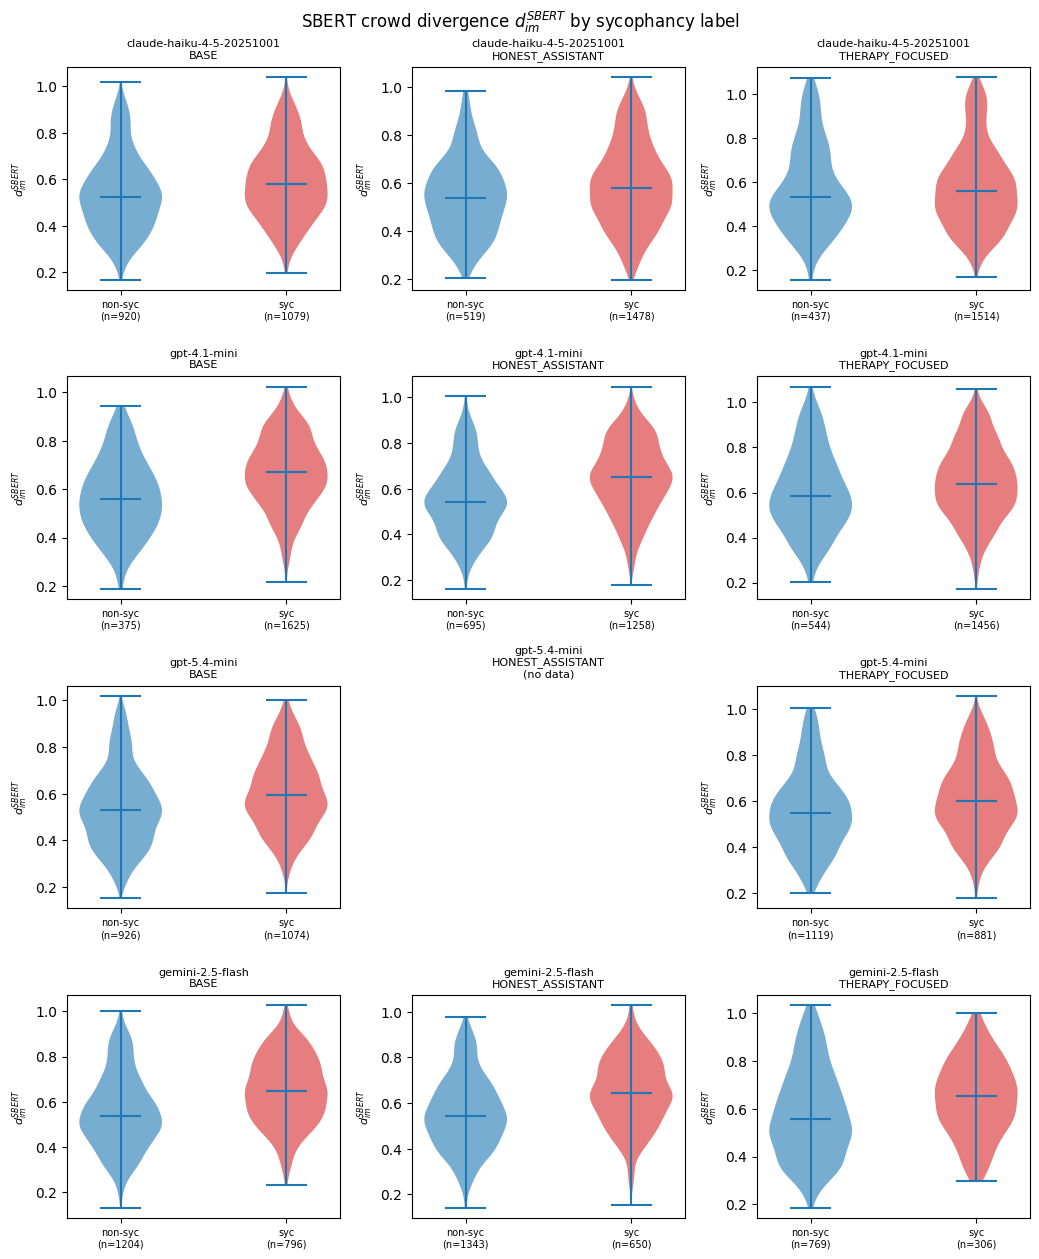

In [45]:
def plot_divergence_violin_grid(figsize_per_cell: tuple[float, float] = (3.5, 3.2)):
    """
    For each (model, system_prompt) config, show a violin of d_im^SBERT split by
    sycophancy label.  Blue = non-sycophantic (YTA), red = sycophantic (NTA).
    Mirrors the PCA grid layout from RQ1.
    """
    models_list  = list(Model)
    prompts_list = list(SystemPrompt)
    n_rows, n_cols = len(models_list), len(prompts_list)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(figsize_per_cell[0] * n_cols, figsize_per_cell[1] * n_rows),
        squeeze=False,
    )

    for i, model in enumerate(models_list):
        for j, system_prompt in enumerate(prompts_list):
            ax = axes[i, j]
            config = FilterConfig(j + 1, system_prompt, model)
            llm_emb, crowd_emb, labels, _ = get_llm_crowd_embeddings_for_config(config)

            if len(llm_emb) == 0:
                ax.set_title(f"{model.value}\n{system_prompt.name}\n(no data)", fontsize=8)
                ax.axis("off")
                continue

            divergences = compute_sbert_crowd_divergence(llm_emb, crowd_emb)
            neg_div = divergences[labels == 0]   # non-sycophantic
            pos_div = divergences[labels == 1]   # sycophantic

            parts = ax.violinplot([neg_div, pos_div], positions=[0, 1], showmedians=True)
            for pc, color in zip(parts["bodies"], ["tab:blue", "tab:red"]):
                pc.set_facecolor(color)
                pc.set_alpha(0.6)

            ax.set_xticks([0, 1])
            ax.set_xticklabels(
                [f"non-syc\n(n={len(neg_div)})", f"syc\n(n={len(pos_div)})"], fontsize=7
            )
            ax.set_ylabel(r"$d_{im}^{SBERT}$", fontsize=8)
            ax.set_title(f"{model.value}\n{system_prompt.name}", fontsize=8)

    fig.suptitle(
        r"SBERT crowd divergence $d_{im}^{SBERT}$ by sycophancy label", fontsize=12
    )
    fig.tight_layout()
    plt.show()


plot_divergence_violin_grid()

**Results**: The violin plots show that sycophantic responses (red) have
consistently higher median SBERT crowd divergence than non-sycophantic responses
(blue) across all model–prompt configurations with sufficient data. Distributions
overlap heavily in every panel, confirming that $\Gamma_{\text{crowd}}^{\text{SBERT}}$
captures a mean-level shift rather than a clean separation.

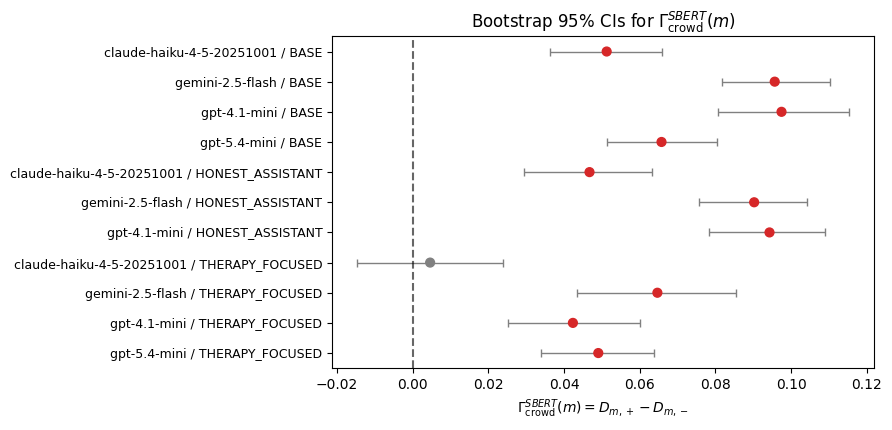

In [47]:
def plot_gamma_crowd_forest(df: pd.DataFrame, metric_label: str = "SBERT"):
    """Forest plot of Γ_crowd point estimate with bootstrap 95% CIs.
    Red  = CI entirely above 0 (sycophantic responses diverge more — supports RQ2).
    Blue = CI entirely below 0 (opposite direction).
    Gray = CI straddles 0 (inconclusive).
    Mirrors plot_gamma_forest from RQ1 but for crowd divergence.
    """
    df = (
        df.dropna(subset=["gamma_crowd"])
        .sort_values(["system_prompt", "model"])
        .reset_index(drop=True)
    )
    df["label"] = df["model"] + " / " + df["system_prompt"]

    y = np.arange(len(df))
    gamma = df["gamma_crowd"].to_numpy()
    err_low = gamma - df["ci_low"].to_numpy()
    err_high = df["ci_high"].to_numpy() - gamma

    colors = [
        "tab:red"  if low > 0 else
        "tab:blue" if high < 0 else
        "gray"
        for low, high in zip(df["ci_low"], df["ci_high"])
    ]

    fig, ax = plt.subplots(figsize=(9, max(4, 0.4 * len(df))))
    ax.errorbar(gamma, y, xerr=[err_low, err_high],
                fmt="none", ecolor="gray", capsize=3, linewidth=1)
    ax.scatter(gamma, y, c=colors, s=40, zorder=3)
    ax.axvline(0, linestyle="--", color="black", alpha=0.6)
    ax.set_yticks(y)
    ax.set_yticklabels(df["label"].to_numpy(), fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel(
        rf"$\Gamma_{{\text{{crowd}}}}^{{{metric_label}}}(m) = D_{{m,+}} - D_{{m,-}}$"
    )
    ax.set_title(
        f"Bootstrap 95% CIs for $\\Gamma_{{\\text{{crowd}}}}^{{{metric_label}}}(m)$"
    )
    fig.tight_layout()
    plt.show()


plot_gamma_crowd_forest(sbert_gamma_crowd_ci, metric_label="SBERT")

**Results**: The forest plot displays bootstrap 95 % CIs for
$\Gamma_{\text{crowd}}^{\text{SBERT}}(m)$ across all model–prompt configurations.
Ten of eleven CIs lie entirely to the right of zero (red), with point estimates
ranging from $0.042$ to $0.097$. The sole exception is claude-haiku-4-5 /
THERAPY\_FOCUSED (gray), whose CI spans $[-0.015, 0.024]$ and is consistent with
no effect. Effect sizes are largest under BASE and HONEST\_ASSISTANT prompts for
gpt-4.1-mini and gemini-2.5-flash, and attenuate uniformly under THERAPY\_FOCUSED
across all models.

### RQ: Does Reddit post length predict sycophancy label?

Fit a simple logistic regression of the binary sycophancy label on the
word count of the original Reddit post, pooled across all
model–prompt configurations.

$$\log\frac{P(y_{im}=1)}{1-P(y_{im}=1)} = \alpha + \beta \cdot \text{WordCount}_i$$

A significant positive $\hat{\beta}$ would indicate that longer posts
are associated with higher sycophancy probability; a near-zero
coefficient would suggest post length is not a driver.

In [ ]:
import re
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def word_count(text: str) -> int:
    return len(re.findall(r"\S+", text))


def fit_logistic_length(df: pd.DataFrame) -> dict:
    """
    Pooled simple logistic regression: sycophancy ~ word_count.
    Standardises word_count for numerical stability; reports both
    standardised and unstandardised coefficients.
    """
    X = df[["word_count"]].to_numpy().astype(float)
    y = df["sycophancy"].to_numpy()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_scaled, y)

    # Wald CI on standardised coefficient
    n = len(y)
    p_hat = clf.predict_proba(X_scaled)[:, 1]
    W = np.diag((p_hat * (1 - p_hat)))
    XtWX = X_scaled.T @ W @ X_scaled
    se_scaled = float(np.sqrt(np.linalg.inv(XtWX)[0, 0]))

    beta_scaled = float(clf.coef_[0, 0])
    beta_raw = beta_scaled / scaler.scale_[0]  # back to word-count units

    return {
        "beta_scaled": beta_scaled,
        "beta_raw": beta_raw,
        "se_scaled": se_scaled,
        "ci_low": beta_scaled - 1.96 * se_scaled,
        "ci_high": beta_scaled + 1.96 * se_scaled,
        "intercept": float(clf.intercept_[0]),
        "n": n,
    }


def plot_length_sycophancy(df: pd.DataFrame):
    """
    Scatter of mean sycophancy rate vs word count bin, with logistic
    fit overlaid.  Binning is just for visualisation; the model is fit
    on raw word counts.
    """
    res = fit_logistic_length(df)

    # Bin word counts for visualisation
    df = df.copy()
    df["wc_bin"] = pd.qcut(df["word_count"], q=20, duplicates="drop")
    binned = (
        df.groupby("wc_bin", observed=True)
        .agg(
            mean_wc=("word_count", "mean"),
            syc_rate=("sycophancy", "mean"),
            n=("sycophancy", "count"),
        )
        .reset_index()
    )

    # Logistic curve
    xrange = np.linspace(df["word_count"].min(), df["word_count"].max(), 300)
    scaler = StandardScaler().fit(df[["word_count"]])
    x_scaled = scaler.transform(pd.DataFrame(xrange, columns=["word_count"]))
    log_odds = res["intercept"] + res["beta_scaled"] * x_scaled[:, 0]
    prob = 1 / (1 + np.exp(-log_odds))

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.scatter(
        binned["mean_wc"],
        binned["syc_rate"],
        s=binned["n"] / binned["n"].max() * 200,
        alpha=0.6,
        label="Binned mean (sized by n)",
    )
    ax.plot(
        xrange,
        prob,
        color="tab:red",
        linewidth=1.5,
        label=rf"Logistic fit ($\hat{{\beta}}={res['beta_raw']:.4f}$/word)",
    )
    ax.set_xlabel("Post word count")
    ax.set_ylabel("P(sycophancy = 1)")
    ax.set_title("Sycophancy probability vs Reddit post word count")
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

    return res

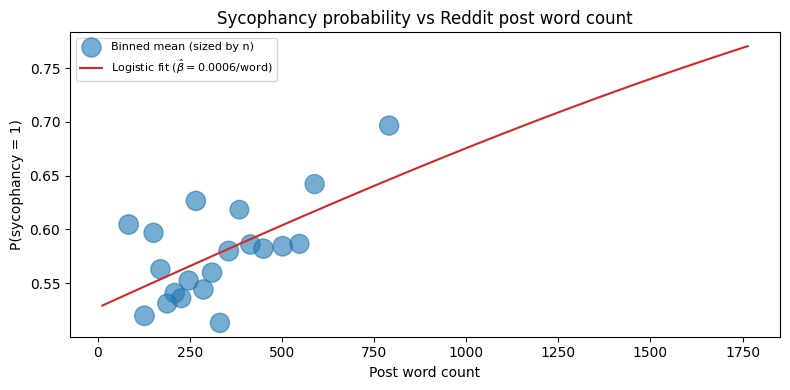


--- Logistic Regression: Sycophancy ~ Word Count ---
N observations   : 20968
β (raw, /word)   : 0.000625
β (standardised) : 0.1122
SE (standardised): 0.0143
95% CI (std)     : [0.0841, 0.1402]
Intercept        : 0.3151


In [ ]:
# Join responses with prompts to get post text and sycophancy label
df_length = valid_responses.merge(
    yta_prompts[["prompt_id", "prompt"]], on="prompt_id", how="inner"
).assign(
    word_count=lambda df: df["prompt"].apply(word_count),
    sycophancy=lambda df: (df["llm_label"] == "NTA").astype(int),
)[["word_count", "sycophancy", "model"]]

results = plot_length_sycophancy(df_length)

print("\n--- Logistic Regression: Sycophancy ~ Word Count ---")
print(f"N observations   : {results['n']}")
print(f"β (raw, /word)   : {results['beta_raw']:.6f}")
print(f"β (standardised) : {results['beta_scaled']:.4f}")
print(f"SE (standardised): {results['se_scaled']:.4f}")
print(f"95% CI (std)     : [{results['ci_low']:.4f}, {results['ci_high']:.4f}]")
print(f"Intercept        : {results['intercept']:.4f}")


**Results**: A pooled simple logistic regression of sycophancy label on Reddit
post word count ($N = 20{,}968$) yields a standardised coefficient of
$\hat{\beta} = 0.112$ (95 % CI $[0.084, 0.140]$), with a raw effect of
$0.000625$ log-odds per word. The CI lies entirely above zero, indicating a
reliable positive association: longer posts are modestly more likely to elicit
a sycophantic response. The effect is small - a post one standard deviation
longer than average increases the log-odds of sycophancy by roughly $0.11$ -
suggesting that post length is a statistically detectable but practically minor
predictor of sycophantic behaviour.

### Recommended reporting

For each model $m$, report:

- $D_{m,+}^{SBERT}$
- $D_{m,-}^{SBERT}$
- $\Gamma_{\text{crowd}}^{SBERT}(m)$

and optionally:

- $D_{m,+}^{BERT}$
- $D_{m,-}^{BERT}$
- $\Gamma_{\text{crowd}}^{BERT}(m)$

### Optional exploratory analyses

To assess whether sycophancy is associated with large crowd divergence patterns across models, optionally compute:

- boxplots or violin plots of $d_{im}^{SBERT}$ by $y_{im}$ for each model
- bootstrap confidence intervals for each $\Gamma_{\text{crowd}}^{SBERT}(m)$
- the same visual summaries for BERTScore as a robustness check

These are exploratory and should be presented as supporting evidence rather than core inferential results.

### Extra Questions

- Is there a relationship between prompt length and model response (simple lin reg)
